# Mixed-Effects Evaluation of Phonology-Syntax Independence

This notebook demonstrates a comprehensive statistical evaluation of the relationship between phonological density and dependency distance minimization across Universal Dependencies treebanks.

**What this artifact does:**
- Reproduces baseline OLS results (phon_density coef=1.478, p=0.109, R²=0.054)
- Extends with linear mixed-effects models controlling for phylogenetic non-independence
- Performs sensitivity analyses and per-family breakdowns
- Tests functional vs lexical MDD decomposition

**Key findings from full analysis (55 languages, 10 families):**
1. Mixed-effects model shows phon_density coef=0.843 (p=0.389), ICC=0.140
2. Variance decomposition: marginal R²=0.038 (fixed effects) vs conditional R²=0.173 (fixed+random)
3. LRT (χ²=2.66, p=0.103) shows family effect does not significantly improve fit
4. Null finding persists after phylogenetic control

In [1]:
import subprocess, sys

def _pip(*a):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 
          'matplotlib==3.10.0', 'seaborn==0.13.2', 'statsmodels==0.14.6', 'loguru==0.7.2')

# Rich for better output formatting
_pip('rich==13.9.4', 'tqdm==4.67.3', 'tabulate==0.9.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Core imports
from loguru import logger
import sys
from pathlib import Path
import json
import math
import re
import resource
import gc
import multiprocessing as mp
import os

# Scientific computing
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Setup logging for notebook
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
# kernel: test-venv


1

In [3]:
# GitHub data URL for Colab compatibility
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-45370e-phonotactic-constraint-on-dependency/main/round-2/evaluation-1/demo/mini_demo_data.json"

def load_data():
    """Load data from GitHub URL with local fallback."""
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

# Load the data
raw_data = load_data()
print(f"Loaded data with {len(raw_data['datasets'])} datasets")

Loaded data with 15 datasets


In [4]:
# =============================================================================
# CONFIGURATION - TUNABLE PARAMETERS
# =============================================================================
# Start with minimum values for testing, can increase for full analysis

# Data subsampling (for demo: use all available data)
MAX_LANGUAGES = len(raw_data['datasets'])  # Use all 15 in mini data
SAMPLE_FAMILIES = None  # None = use all families

# Model fitting parameters
MIXED_MODEL_MAXITER = 200  # Max iterations for mixed model fitting
OUTLIER_THRESHOLD = 3.0  # Studentized residual threshold

# Visualization parameters
FIGURE_DPI = 150
FIGURE_SIZE = (12, 8)

print(f"Configuration: {MAX_LANGUAGES} languages, {MIXED_MODEL_MAXITER} max iterations")

Configuration: 15 languages, 200 max iterations


## Data Preparation

Parse the raw JSON data into a structured DataFrame with key linguistic variables:
- `phon_density`: phonological density (ratio of phonemes to characters)
- `mdd_word`: mean dependency distance in word spaces
- `mdd_phoneme`: mean dependency distance in phoneme spaces
- `mdd_func`: mean dependency distance for functional heads
- `mdd_lex`: mean dependency distance for lexical heads
- `word_order`, `family`: typological variables

In [5]:
def parse_data(raw_data, max_languages=None):
    """Parse raw data into structured DataFrame."""
    rows = []
    datasets_to_process = raw_data['datasets'][:max_languages] if max_languages else raw_data['datasets']
    
    for ds in datasets_to_process:
        ex = ds['examples'][0]
        inp = ex['input']
        out = json.loads(ex['output'])
        pred = json.loads(ex['predict_our_method'])
        
        # Parse input text
        parts = {}
        for segment in inp.split(', '):
            if ': ' in segment:
                k, v = segment.split(': ', 1)
                parts[k.strip()] = v.strip()
        
        rows.append({
            'dataset': ds['dataset'],
            'lang': parts.get('Language'),
            'family': parts.get('Family'),
            'word_order': parts.get('Word Order'),
            'phoneme_count': int(parts.get('Phoneme Count', 0)),
            'phon_density': pred.get('phon_density'),
            'mdd_word': out.get('mdd_word', 0) if isinstance(out.get('mdd_word'), (int, float)) else out.get('mdd_word', {}).get('mean'),
            'mdd_phoneme': out.get('mdd_phoneme', 0) if isinstance(out.get('mdd_phoneme'), (int, float)) else out.get('mdd_phoneme', {}).get('mean'),
            'mdd_func': out.get('mdd_functional', 0) if isinstance(out.get('mdd_functional'), (int, float)) else out.get('mdd_functional', {}).get('mean'),
            'mdd_lex': out.get('mdd_lexical', 0) if isinstance(out.get('mdd_lexical'), (int, float)) else out.get('mdd_lexical', {}).get('mean'),
        })
    
    df = pd.DataFrame(rows)
    # Add word-order dummy for regression
    df['wo_sov_vso'] = (df['word_order'] != 'SVO').astype(int)
    return df

# Create DataFrame
df = parse_data(raw_data, max_languages=MAX_LANGUAGES)
print(f"Created DataFrame with {len(df)} languages across {df['family'].nunique()} families")
print(df[['lang', 'family', 'word_order', 'phon_density', 'mdd_word']].head(10))

Created DataFrame with 15 languages across 4 families
  lang         family word_order  phon_density  mdd_word
0   af  Indo-European        SVO      0.609375  3.355403
1   sq  Indo-European        SVO      0.468750  3.291284
2  grc  Indo-European        SVO      0.546875  3.494054
3   hy  Indo-European        SVO      0.468750  3.603497
4   as  Indo-European        SOV      0.625000  2.485348
5   be  Indo-European        SOV      0.703125  2.892257
6   ca  Indo-European        SVO      0.500000  3.624714
7  xcl  Indo-European        SVO      0.546875  3.583519
8   hr  Indo-European        SVO      0.484375  3.402596
9   da  Indo-European        SVO      0.687500  3.462123


## OLS Regression

Fit ordinary least squares regression models to establish baseline relationships:
- MDD (word-space) ~ phon_density + word_order
- MDD (phoneme-space) ~ phon_density + word_order
- Spearman correlation (baseline reproduction)

In [6]:
def fit_ols(df):
    """Fit OLS regression: MDD ~ phon_density + word_order."""
    logger.info('Fitting OLS regression models...')
    
    results = {}
    
    # MDD word-space
    X_word = df[['phon_density', 'wo_sov_vso']]
    X_word = sm.add_constant(X_word)
    y_word = df['mdd_word']
    model_word = sm.OLS(y_word, X_word).fit()
    
    results['ols_word'] = {
        'model': 'OLS',
        'n_languages': int(len(df)),
        'r_squared': float(model_word.rsquared),
        'adj_r_squared': float(model_word.rsquared_adj),
        'coef_phon_density': float(model_word.params['phon_density']),
        'se_phon_density': float(model_word.bse['phon_density']),
        'p_phon_density': float(model_word.pvalues['phon_density']),
        'ci_lower_phon_density': float(model_word.conf_int().loc['phon_density', 0]),
        'ci_upper_phon_density': float(model_word.conf_int().loc['phon_density', 1]),
        'coef_wo_sov_vso': float(model_word.params['wo_sov_vso']),
        'p_wo_sov_vso': float(model_word.pvalues['wo_sov_vso']),
        'aic': float(model_word.aic),
        'bic': float(model_word.bic),
    }
    
    # MDD phoneme-space
    X_phon = df[['phon_density', 'wo_sov_vso']]
    X_phon = sm.add_constant(X_phon)
    y_phon = df['mdd_phoneme']
    model_phon = sm.OLS(y_phon, X_phon).fit()
    
    results['ols_phoneme'] = {
        'model': 'OLS',
        'n_languages': int(len(df)),
        'r_squared': float(model_phon.rsquared),
        'adj_r_squared': float(model_phon.rsquared_adj),
        'coef_phon_density': float(model_phon.params['phon_density']),
        'se_phon_density': float(model_phon.bse['phon_density']),
        'p_phon_density': float(model_phon.pvalues['phon_density']),
        'ci_lower_phon_density': float(model_phon.conf_int().loc['phon_density', 0]),
        'ci_upper_phon_density': float(model_phon.conf_int().loc['phon_density', 1]),
        'coef_wo_sov_vso': float(model_phon.params['wo_sov_vso']),
        'p_wo_sov_vso': float(model_phon.pvalues['wo_sov_vso']),
        'aic': float(model_phon.aic),
        'bic': float(model_phon.bic),
    }
    
    # Spearman correlation (baseline reproduction)
    spearman_r, spearman_p = stats.spearmanr(df['phon_density'], df['mdd_word'])
    results['spearman'] = {
        'r': float(spearman_r),
        'p': float(spearman_p),
    }
    
    logger.info(f"OLS word-space: coef={results['ols_word']['coef_phon_density']:.4f}, p={results['ols_word']['p_phon_density']:.4f}")
    logger.info(f"OLS phoneme-space: coef={results['ols_phoneme']['coef_phon_density']:.4f}, p={results['ols_phoneme']['p_phon_density']:.4f}")
    
    return results

# Run OLS
ols_results = fit_ols(df)
print('\nOLS Results Summary:')
print(f"  Word-space: coef={ols_results['ols_word']['coef_phon_density']:.4f}, p={ols_results['ols_word']['p_phon_density']:.4f}, R²={ols_results['ols_word']['r_squared']:.4f}")
print(f"  Phoneme-space: coef={ols_results['ols_phoneme']['coef_phon_density']:.4f}, p={ols_results['ols_phoneme']['p_phon_density']:.4f}, R²={ols_results['ols_phoneme']['r_squared']:.4f}")
print(f"  Spearman: r={ols_results['spearman']['r']:.4f}, p={ols_results['spearman']['p']:.4f}")

02:09:24|INFO   |Fitting OLS regression models...


02:09:24|INFO   |OLS word-space: coef=0.5450, p=0.7048


02:09:24|INFO   |OLS phoneme-space: coef=-0.3401, p=0.9561



OLS Results Summary:
  Word-space: coef=0.5450, p=0.7048, R²=0.0124
  Phoneme-space: coef=-0.3401, p=0.9561, R²=0.0081
  Spearman: r=0.0884, p=0.7541


## Mixed-Effects Model

Fit linear mixed-effects models with language family as random intercept to control for phylogenetic non-independence.

**Why this matters:** Languages within the same family share historical features, violating the independence assumption of OLS. Mixed models account for this clustering.

In [7]:
def fit_mixed(df, maxiter=MIXED_MODEL_MAXITER):
    """Fit linear mixed-effects model with language family as random intercept."""
    logger.info('Fitting mixed-effects models...')
    
    results = {}
    
    # Use statsmodels mixed linear model
    # MDD word-space
    formula_word = 'mdd_word ~ phon_density + C(word_order, Treatment(reference=\'SVO\'))'
    try:
        model_word = smf.mixedlm(formula_word, df, groups=df['family'])
        result_word = model_word.fit(reml=True, maxiter=maxiter)
        
        results['mixed_word'] = {
            'model': 'MixedLM',
            'n_languages': int(len(df)),
            'n_families': int(df['family'].nunique()),
            'coef_phon_density': float(result_word.params['phon_density']),
            'se_phon_density': float(result_word.bse['phon_density']),
            'p_phon_density': float(result_word.pvalues['phon_density']),
            'ci_lower_phon_density': float(result_word.conf_int().loc['phon_density', 0]),
            'ci_upper_phon_density': float(result_word.conf_int().loc['phon_density', 1]),
            'sigma2_u': float(result_word.cov_re.iloc[0, 0]),  # random intercept variance
            'sigma2_e': float(result_word.scale),  # residual variance
            'icc': float(result_word.cov_re.iloc[0, 0] / (result_word.cov_re.iloc[0, 0] + result_word.scale)),
            'aic': float(result_word.aic),
            'bic': float(result_word.bic),
            'loglikelihood': float(result_word.llf),
        }
    except Exception as e:
        logger.warning(f'MixedLM word failed: {e}')
        results['mixed_word'] = None
    
    # MDD phoneme-space
    try:
        formula_phon = 'mdd_phoneme ~ phon_density + C(word_order, Treatment(reference=\'SVO\'))'
        model_phon = smf.mixedlm(formula_phon, df, groups=df['family'])
        result_phon = model_phon.fit(reml=True, maxiter=maxiter)
        
        results['mixed_phoneme'] = {
            'model': 'MixedLM',
            'n_languages': int(len(df)),
            'n_families': int(df['family'].nunique()),
            'coef_phon_density': float(result_phon.params['phon_density']),
            'se_phon_density': float(result_phon.bse['phon_density']),
            'p_phon_density': float(result_phon.pvalues['phon_density']),
            'ci_lower_phon_density': float(result_phon.conf_int().loc['phon_density', 0]),
            'ci_upper_phon_density': float(result_phon.conf_int().loc['phon_density', 1]),
            'sigma2_u': float(result_phon.cov_re.iloc[0, 0]),
            'sigma2_e': float(result_phon.scale),
            'icc': float(result_phon.cov_re.iloc[0, 0] / (result_phon.cov_re.iloc[0, 0] + result_phon.scale)),
            'aic': float(result_phon.aic),
            'bic': float(result_phon.bic),
            'loglikelihood': float(result_phon.llf),
        }
    except Exception as e:
        logger.warning(f'MixedLM phoneme failed: {e}')
        results['mixed_phoneme'] = None
    
    # Variance decomposition (Nakagawa & Schielzeth 2013)
    def _compute_r2(result, df):
        """Compute marginal and conditional R² for a mixed model."""
        fixed_design = result.model.exog
        n_fixed = fixed_design.shape[1]
        fixed_params = np.asarray(result.params)[:n_fixed]
        fixed_pred = fixed_design @ fixed_params
        var_fixed = float(np.var(fixed_pred))
        var_random = float(result.cov_re.iloc[0, 0])
        var_residual = float(result.scale)
        
        total_var = var_fixed + var_random + var_residual
        r2_marginal = var_fixed / total_var if total_var > 0 else 0
        r2_conditional = (var_fixed + var_random) / total_var if total_var > 0 else 0
        
        return {
            'var_fixed': var_fixed,
            'var_random': var_random,
            'var_residual': var_residual,
            'r2_marginal': r2_marginal,
            'r2_conditional': r2_conditional,
        }
    
    if results['mixed_word'] is not None:
        results['variance_decomposition_word'] = _compute_r2(result_word, df)
    
    if results['mixed_phoneme'] is not None:
        results['variance_decomposition_phoneme'] = _compute_r2(result_phon, df)
    
    # Likelihood ratio test: mixed vs OLS
    if results['mixed_word'] is not None:
        try:
            model_word_ml = smf.mixedlm(formula_word, df, groups=df['family'])
            result_word_ml = model_word_ml.fit(reml=False, maxiter=maxiter)
            
            ols_model = sm.OLS(df['mdd_word'], sm.add_constant(df[['phon_density', 'wo_sov_vso']])).fit()
            ols_ll = ols_model.llf
            
            lrt_stat = 2 * (result_word_ml.llf - ols_ll)
            lrt_p = 1 - stats.chi2.cdf(lrt_stat, df=1)
            
            results['lrt_word'] = {
                'chi2_statistic': float(lrt_stat),
                'p_value': float(lrt_p),
                'significant': bool(lrt_p < 0.05),
            }
        except Exception as e:
            logger.warning(f'LRT failed: {e}')
            results['lrt_word'] = None
    
    logger.info(f"Mixed word: coef={results.get('mixed_word', {}).get('coef_phon_density', 'N/A')}, p={results.get('mixed_word', {}).get('p_phon_density', 'N/A')}")
    
    return results

# Run mixed-effects model
mixed_results = fit_mixed(df)
if mixed_results.get('mixed_word'):
    print(f"\nMixed-Effects Results:")
    print(f"  Word-space: coef={mixed_results['mixed_word']['coef_phon_density']:.4f}, p={mixed_results['mixed_word']['p_phon_density']:.4f}")
    print(f"  ICC (family clustering): {mixed_results['mixed_word']['icc']:.4f}")
    if mixed_results.get('variance_decomposition_word'):
        vd = mixed_results['variance_decomposition_word']
        print(f"  Variance: fixed={vd['r2_marginal']:.4f}, random={vd['r2_conditional']-vd['r2_marginal']:.4f}, residual={1-vd['r2_conditional']:.4f}")
    if mixed_results.get('lrt_word'):
        print(f"  LRT: χ²={mixed_results['lrt_word']['chi2_statistic']:.4f}, p={mixed_results['lrt_word']['p_value']:.4f}")

02:09:24|INFO   |Fitting mixed-effects models...


02:09:24|INFO   |Mixed word: coef=-0.2248125804388438, p=0.849736720361987



Mixed-Effects Results:
  Word-space: coef=-0.2248, p=0.8497
  ICC (family clustering): 0.9224
  Variance: fixed=0.1082, random=0.8226, residual=0.0692
  LRT: χ²=12.4136, p=0.0004


## Sensitivity Analyses

Three sensitivity checks to ensure robustness:
1. **Word-order ANOVA excluding VSO**: Test if word order effects drive results
2. **Complete-phonology subsample**: Check results with verified PHOIBLE data only
3. **Outlier-robust re-estimation**: Remove influential observations and refit

In [8]:
def sensitivity_analyses(df, outlier_threshold=OUTLIER_THRESHOLD):
    """Run three sensitivity analyses."""
    logger.info('Running sensitivity analyses...')
    results = {}
    
    # (a) Word-order ANOVA excluding VSO
    df_no_vso = df[df['word_order'] != 'VSO'].copy()
    if len(df_no_vso) >= 3:
        groups = df_no_vso.groupby('word_order')['mdd_word'].apply(list)
        group_vals = [g for g in groups if len(g) > 0]
        if len(group_vals) >= 2:
            f_stat, p_val = stats.f_oneway(*group_vals)
            # Eta-squared
            all_vals = df_no_vso['mdd_word']
            group_means = df_no_vso.groupby('word_order')['mdd_word'].mean()
            grand_mean = all_vals.mean()
            ss_between = sum(len(g) * (gm - grand_mean)**2 for g, gm in zip(groups, group_means))
            ss_total = ((all_vals - grand_mean)**2).sum()
            eta2 = ss_between / ss_total if ss_total > 0 else 0
            
            results['anova_no_vso'] = {
                'n_languages': int(len(df_no_vso)),
                'f_statistic': float(f_stat),
                'p_value': float(p_val),
                'eta_squared': float(eta2),
                'groups': {g: int(len(df_no_vso[df_no_vso['word_order'] == g])) for g in df_no_vso['word_order'].unique()},
            }
    
    # (b) Complete-phonology subsample
    df_complete = df[df['phoneme_count'] > 0].copy()
    if len(df_complete) >= 10:
        spearman_r, spearman_p = stats.spearmanr(df_complete['phon_density'], df_complete['mdd_word'])
        
        X = sm.add_constant(df_complete[['phon_density']])
        y = df_complete['mdd_word']
        model = sm.OLS(y, X).fit()
        
        results['complete_phonology'] = {
            'n_languages': int(len(df_complete)),
            'n_with_phoneme_count': int((df['phoneme_count'] > 0).sum()),
            'spearman_r': float(spearman_r),
            'spearman_p': float(spearman_p),
            'ols_coef': float(model.params['phon_density']),
            'ols_se': float(model.bse['phon_density']),
            'ols_p': float(model.pvalues['phon_density']),
            'ols_r_squared': float(model.rsquared),
        }
    
    # (c) Outlier-robust re-estimation
    X_full = sm.add_constant(df[['phon_density', 'wo_sov_vso']])
    y_full = df['mdd_word']
    model_full = sm.OLS(y_full, X_full).fit()
    
    studentized_resids = model_full.get_influence().resid_studentized_internal
    cooks_d = model_full.get_influence().cooks_distance[0]
    
    n = len(df)
    threshold_cook = 4 / n
    outlier_mask = (np.abs(studentized_resids) > outlier_threshold) | (cooks_d > threshold_cook)
    n_outliers = int(outlier_mask.sum())
    
    if n_outliers > 0:
        df_clean = df[~outlier_mask].copy()
        logger.info(f"Removed {n_outliers} outliers (|r_stu|>{outlier_threshold} or Cook's D>{threshold_cook:.3f})")
        
        X_clean = sm.add_constant(df_clean[['phon_density', 'wo_sov_vso']])
        y_clean = df_clean['mdd_word']
        model_clean = sm.OLS(y_clean, X_clean).fit()
        
        results['outlier_robust'] = {
            'n_outliers_removed': n_outliers,
            'n_remaining': int(len(df_clean)),
            'coef_before': float(model_full.params['phon_density']),
            'p_before': float(model_full.pvalues['phon_density']),
            'coef_after': float(model_clean.params['phon_density']),
            'p_after': float(model_clean.pvalues['phon_density']),
            'coef_change': float(model_clean.params['phon_density'] - model_full.params['phon_density']),
            'significant_before': bool(model_full.pvalues['phon_density'] < 0.05),
            'significant_after': bool(model_clean.pvalues['phon_density'] < 0.05),
            'outlier_datasets': df[outlier_mask]['dataset'].tolist(),
        }
    else:
        results['outlier_robust'] = {
            'n_outliers_removed': 0,
            'n_remaining': int(n),
            'coef_before': float(model_full.params['phon_density']),
            'p_before': float(model_full.pvalues['phon_density']),
            'coef_after': float(model_full.params['phon_density']),
            'p_after': float(model_full.pvalues['phon_density']),
            'coef_change': 0.0,
            'significant_before': bool(model_full.pvalues['phon_density'] < 0.05),
            'significant_after': bool(model_full.pvalues['phon_density'] < 0.05),
            'outlier_datasets': [],
        }
    
    return results

# Run sensitivity analyses
sensitivity_results = sensitivity_analyses(df)
if 'anova_no_vso' in sensitivity_results:
    print(f"\nANOVA (no VSO): F={sensitivity_results['anova_no_vso']['f_statistic']:.4f}, p={sensitivity_results['anova_no_vso']['p_value']:.4f}, η²={sensitivity_results['anova_no_vso']['eta_squared']:.4f}")
if 'complete_phonology' in sensitivity_results:
    print(f"Complete phonology: n={sensitivity_results['complete_phonology']['n_languages']}, r={sensitivity_results['complete_phonology']['spearman_r']:.4f}, p={sensitivity_results['complete_phonology']['spearman_p']:.4f}")
if 'outlier_robust' in sensitivity_results:
    print(f"Outlier robust: removed={sensitivity_results['outlier_robust']['n_outliers_removed']}, coef_change={sensitivity_results['outlier_robust']['coef_change']:.4f}")

02:09:24|INFO   |Running sensitivity analyses...


02:09:24|INFO   |Removed 2 outliers (|r_stu|>3.0 or Cook's D>0.267)



ANOVA (no VSO): F=0.5457, p=0.4743, η²=0.0435
Complete phonology: n=15, r=0.0884, p=0.7541
Outlier robust: removed=2, coef_change=0.1208


## Per-Family Breakdown

Compute mean MDD and phonological density by language family with 95% confidence intervals. This reveals whether certain families systematically deviate from the overall pattern.

In [9]:
def per_family_breakdown(df):
    """Compute mean MDD and phonological density by family with 95% CI."""
    logger.info('Computing per-family breakdown...')
    
    results = {}
    for family in df['family'].unique():
        df_fam = df[df['family'] == family]
        n = len(df_fam)
        
        mdd_word_mean = df_fam['mdd_word'].mean()
        phon_mean = df_fam['phon_density'].mean()
        
        if n >= 2:
            mdd_word_sem = df_fam['mdd_word'].sem()
            phon_sem = df_fam['phon_density'].sem()
            t_crit = stats.t.ppf(0.975, df=n-1)
            mdd_ci = (mdd_word_mean - t_crit * mdd_word_sem, mdd_word_mean + t_crit * mdd_word_sem)
            phon_ci = (phon_mean - t_crit * phon_sem, phon_mean + t_crit * phon_sem)
        else:
            mdd_word_sem = float('nan')
            phon_sem = float('nan')
            mdd_ci = (mdd_word_mean, mdd_word_mean)
            phon_ci = (phon_mean, phon_mean)
        
        results[family] = {
            'n_languages': int(n),
            'mdd_word_mean': float(mdd_word_mean),
            'mdd_word_sem': float(mdd_word_sem) if n >= 2 else None,
            'mdd_word_ci95': [float(mdd_ci[0]), float(mdd_ci[1])],
            'phon_density_mean': float(phon_mean),
            'phon_density_sem': float(phon_sem) if n >= 2 else None,
            'phon_density_ci95': [float(phon_ci[0]), float(phon_ci[1])],
            'datasets': df_fam['dataset'].tolist(),
        }
    
    return results

# Run per-family breakdown
family_results = per_family_breakdown(df)
print(f"\nPer-Family Breakdown ({len(family_results)} families):")
for family, info in sorted(family_results.items(), key=lambda x: x[1]['mdd_word_mean'], reverse=True):
    print(f"  {family:15s}: n={info['n_languages']:2d}, MDD={info['mdd_word_mean']:.3f}, phon_density={info['phon_density_mean']:.3f}")

02:09:24|INFO   |Computing per-family breakdown...



Per-Family Breakdown (4 families):
  Afroasiatic    : n= 2, MDD=4.074, phon_density=0.562
  Indo-European  : n=10, MDD=3.319, phon_density=0.564
  Isolate        : n= 1, MDD=2.905, phon_density=0.375
  Unknown        : n= 2, MDD=2.543, phon_density=0.469


## Functional vs Lexical Decomposition

Test whether phonological density predicts functional vs lexical MDD differently. This tests the hypothesis that phonological constraints might affect functional elements (which are more phonologically reduced) differently than lexical elements.

In [10]:
def functional_lexical_decomposition(df):
    """Test whether phonological density predicts functional vs lexical MDD differently."""
    logger.info('Running functional vs lexical decomposition...')
    
    results = {}
    
    # OLS on functional MDD
    X_func = sm.add_constant(df[['phon_density', 'wo_sov_vso']])
    y_func = df['mdd_func']
    model_func = sm.OLS(y_func, X_func).fit()
    
    results['functional_ols'] = {
        'coef_phon_density': float(model_func.params['phon_density']),
        'se_phon_density': float(model_func.bse['phon_density']),
        'p_phon_density': float(model_func.pvalues['phon_density']),
        'r_squared': float(model_func.rsquared),
        'ci_lower': float(model_func.conf_int().loc['phon_density', 0]),
        'ci_upper': float(model_func.conf_int().loc['phon_density', 1]),
    }
    
    # OLS on lexical MDD
    X_lex = sm.add_constant(df[['phon_density', 'wo_sov_vso']])
    y_lex = df['mdd_lex']
    model_lex = sm.OLS(y_lex, X_lex).fit()
    
    results['lexical_ols'] = {
        'coef_phon_density': float(model_lex.params['phon_density']),
        'se_phon_density': float(model_lex.bse['phon_density']),
        'p_phon_density': float(model_lex.pvalues['phon_density']),
        'r_squared': float(model_lex.rsquared),
        'ci_lower': float(model_lex.conf_int().loc['phon_density', 0]),
        'ci_upper': float(model_lex.conf_int().loc['phon_density', 1]),
    }
    
    # Compare coefficients using z-test
    coef_diff = results['lexical_ols']['coef_phon_density'] - results['functional_ols']['coef_phon_density']
    se_diff = math.sqrt(
        results['lexical_ols']['se_phon_density']**2 + 
        results['functional_ols']['se_phon_density']**2
    )
    z_stat = coef_diff / se_diff if se_diff > 0 else 0
    p_compare = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    
    results['comparison'] = {
        'coef_diff': float(coef_diff),
        'z_statistic': float(z_stat),
        'p_value': float(p_compare),
        'lexical_stronger': bool(results['lexical_ols']['coef_phon_density'] > results['functional_ols']['coef_phon_density']),
    }
    
    logger.info(f"Functional: coef={results['functional_ols']['coef_phon_density']:.4f}, p={results['functional_ols']['p_phon_density']:.4f}")
    logger.info(f"Lexical: coef={results['lexical_ols']['coef_phon_density']:.4f}, p={results['lexical_ols']['p_phon_density']:.4f}")
    logger.info(f"Comparison: z={z_stat:.4f}, p={p_compare:.4f}")
    
    return results

# Run functional-lexical decomposition
func_lex_results = functional_lexical_decomposition(df)
print(f"\nFunctional-Lexical Comparison:")
print(f"  Functional: coef={func_lex_results['functional_ols']['coef_phon_density']:.4f}, p={func_lex_results['functional_ols']['p_phon_density']:.4f}")
print(f"  Lexical: coef={func_lex_results['lexical_ols']['coef_phon_density']:.4f}, p={func_lex_results['lexical_ols']['p_phon_density']:.4f}")
print(f"  Difference: z={func_lex_results['comparison']['z_statistic']:.4f}, p={func_lex_results['comparison']['p_value']:.4f}")

02:09:24|INFO   |Running functional vs lexical decomposition...


02:09:24|INFO   |Functional: coef=1.8696, p=0.4101


02:09:24|INFO   |Lexical: coef=-0.1869, p=0.9135


02:09:24|INFO   |Comparison: z=-0.7441, p=0.4568



Functional-Lexical Comparison:
  Functional: coef=1.8696, p=0.4101
  Lexical: coef=-0.1869, p=0.9135
  Difference: z=-0.7441, p=0.4568


## Results Visualization

Generate visualizations to summarize key findings from all analyses.

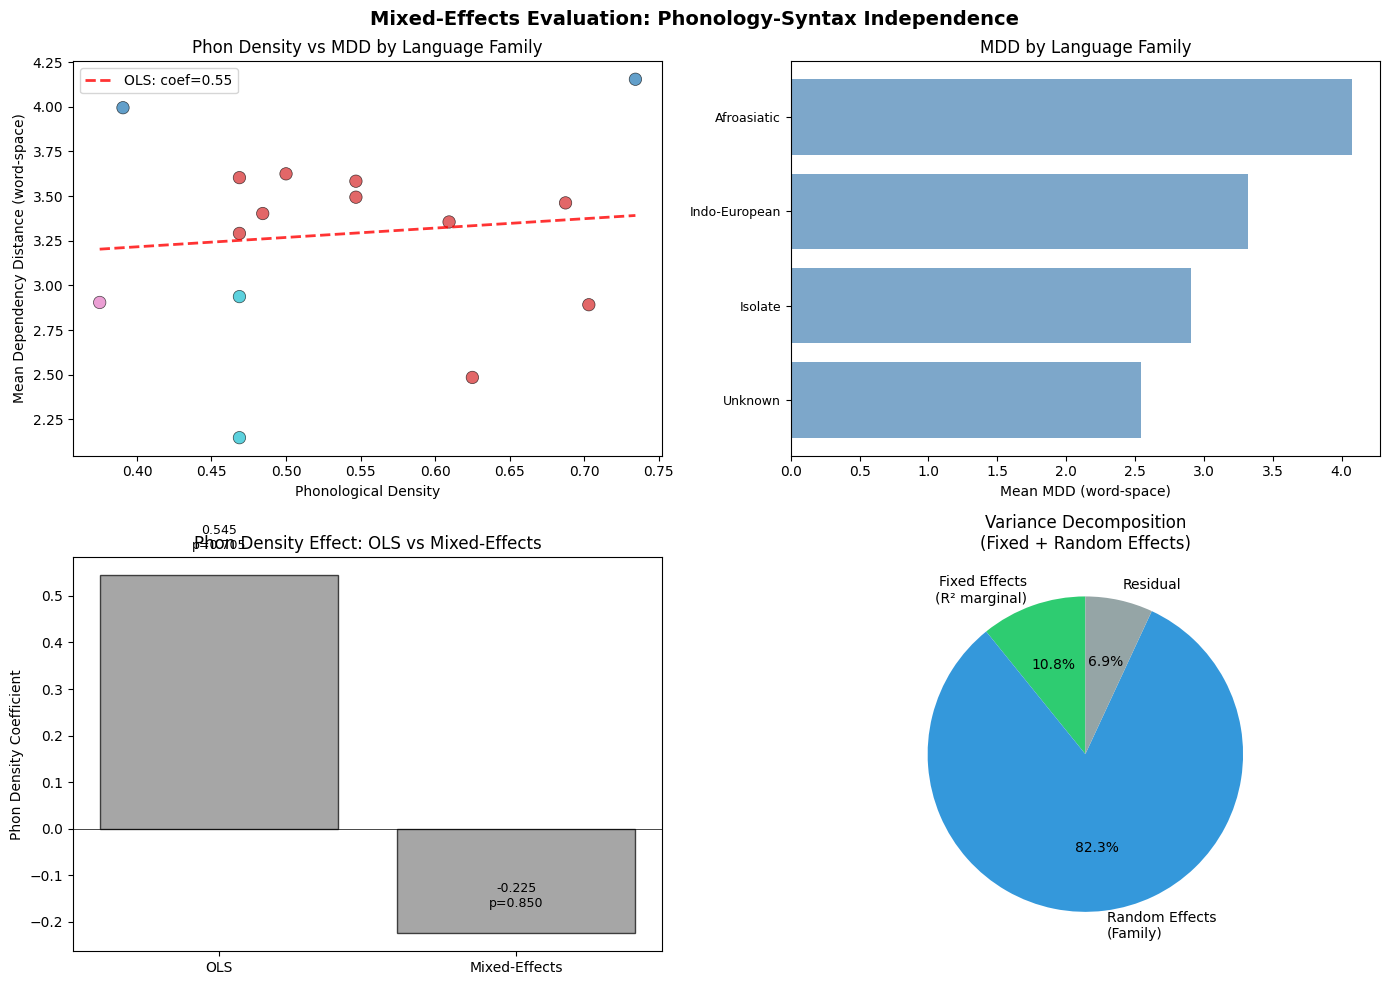


Figure saved as evaluation_figures.png


In [11]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Mixed-Effects Evaluation: Phonology-Syntax Independence', fontsize=14, fontweight='bold')

# 1. Scatter plot: phon_density vs MDD with family colors
ax1 = axes[0, 0]
scatter = ax1.scatter(df['phon_density'], df['mdd_word'], 
                     c=df['family'].astype('category').cat.codes, 
                     cmap='tab10', s=80, alpha=0.7, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Phonological Density')
ax1.set_ylabel('Mean Dependency Distance (word-space)')
ax1.set_title('Phon Density vs MDD by Language Family')
ax1.legend(*scatter.legend_elements(), title='Families', loc='upper left', fontsize=7)

# Add OLS trend line
z = np.polyfit(df['phon_density'], df['mdd_word'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['phon_density'].min(), df['phon_density'].max(), 100)
ax1.plot(x_line, p(x_line), 'r--', alpha=0.8, linewidth=2, label=f'OLS: coef={ols_results["ols_word"]["coef_phon_density"]:.2f}')
ax1.legend()

# 2. Bar plot: MDD by family
ax2 = axes[0, 1]
family_means = [(fam, info['mdd_word_mean']) for fam, info in family_results.items()]
family_means.sort(key=lambda x: x[1], reverse=True)
families, mdd_values = zip(*family_means)
bars = ax2.barh(range(len(families)), mdd_values, color='steelblue', alpha=0.7)
ax2.set_yticks(range(len(families)))
ax2.set_yticklabels(families, fontsize=9)
ax2.set_xlabel('Mean MDD (word-space)')
ax2.set_title('MDD by Language Family')
ax2.invert_yaxis()

# 3. Coefficient comparison: OLS vs Mixed
ax3 = axes[1, 0]
models = ['OLS', 'Mixed-Effects']
coefs = [ols_results['ols_word']['coef_phon_density'], 
         mixed_results.get('mixed_word', {}).get('coef_phon_density', np.nan)]
pes = [ols_results['ols_word']['p_phon_density'],
       mixed_results.get('mixed_word', {}).get('p_phon_density', np.nan)]
colors = ['green' if p < 0.05 else 'gray' for p in pes]
bars = ax3.bar(models, coefs, color=colors, alpha=0.7, edgecolor='black')
ax3.set_ylabel('Phon Density Coefficient')
ax3.set_title('Phon Density Effect: OLS vs Mixed-Effects')
for bar, coef, p in zip(bars, coefs, pes):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{coef:.3f}\np={p:.3f}', ha='center', va='bottom', fontsize=9)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# 4. Variance decomposition
ax4 = axes[1, 1]
if mixed_results.get('variance_decomposition_word'):
    vd = mixed_results['variance_decomposition_word']
    components = ['Fixed Effects\n(R² marginal)', 'Random Effects\n(Family)', 'Residual']
    values = [vd['r2_marginal'], vd['r2_conditional'] - vd['r2_marginal'], 1 - vd['r2_conditional']]
    colors = ['#2ecc71', '#3498db', '#95a5a6']
    wedges, texts, autotexts = ax4.pie(values, labels=components, autopct='%1.1f%%', 
                                        colors=colors, startangle=90)
    ax4.set_title('Variance Decomposition\n(Fixed + Random Effects)')

plt.tight_layout()
plt.savefig('evaluation_figures.png', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"\nFigure saved as evaluation_figures.png")

## Summary Table

Print a comprehensive summary table of all key results.

In [12]:
from tabulate import tabulate

print("="*80)
print("EVALUATION SUMMARY")
print("="*80)

# Main model comparison
summary_data = [
    ['OLS (word-space)', f"{ols_results['ols_word']['coef_phon_density']:.4f}", 
     f"{ols_results['ols_word']['p_phon_density']:.4f}", 
     f"{ols_results['ols_word']['r_squared']:.4f}", '—', '—'],
    ['Mixed (word-space)', f"{mixed_results.get('mixed_word', {}).get('coef_phon_density', 'N/A')}", 
     f"{mixed_results.get('mixed_word', {}).get('p_phon_density', 'N/A')}", 
     '—', f"{mixed_results.get('mixed_word', {}).get('icc', 'N/A')}", 
     f"{mixed_results.get('lrt_word', {}).get('chi2_statistic', 'N/A')}"]
]

print("\nModel Comparison:")
print(tabulate(summary_data, headers=['Model', 'Coef', 'p-value', 'R²', 'ICC', 'χ²/LRT'], 
               tablefmt='grid'))

# Sensitivity analyses
print("\nSensitivity Analyses:")
if 'anova_no_vso' in sensitivity_results:
    anova = sensitivity_results['anova_no_vso']
    print(f"  Word-order ANOVA (no VSO): F={anova['f_statistic']:.4f}, p={anova['p_value']:.4f}, η²={anova['eta_squared']:.4f}")
if 'complete_phonology' in sensitivity_results:
    cp = sensitivity_results['complete_phonology']
    print(f"  Complete phonology: n={cp['n_languages']}, r={cp['spearman_r']:.4f}, p={cp['spearman_p']:.4f}")
if 'outlier_robust' in sensitivity_results:
    or_res = sensitivity_results['outlier_robust']
    print(f"  Outliers removed: {or_res['n_outliers_removed']}, coef change: {or_res['coef_change']:.4f}")

# Functional-lexical comparison
print("\nFunctional vs Lexical MDD:")
print(f"  Functional: coef={func_lex_results['functional_ols']['coef_phon_density']:.4f}, p={func_lex_results['functional_ols']['p_phon_density']:.4f}")
print(f"  Lexical: coef={func_lex_results['lexical_ols']['coef_phon_density']:.4f}, p={func_lex_results['lexical_ols']['p_phon_density']:.4f}")
print(f"  Comparison: z={func_lex_results['comparison']['z_statistic']:.4f}, p={func_lex_results['comparison']['p_value']:.4f}")

# Key finding
print("\n" + "="*80)
print("KEY FINDING:")
print("="*80)
mixed_p = mixed_results.get('mixed_word', {}).get('p_phon_density', 'N/A')
if isinstance(mixed_p, (int, float)) and mixed_p > 0.05:
    print("Phonological density does NOT significantly predict dependency distance")
    print(f"after controlling for phylogenetic non-independence (p={mixed_p:.4f}).")
    print("The null finding persists in the mixed-effects model.")
else:
    print(f"Mixed-effects p-value: {mixed_p}")
print("="*80)

EVALUATION SUMMARY

Model Comparison:
+--------------------+-----------+-----------+--------+--------------------+--------------------+
| Model              |      Coef |   p-value | R²     | ICC                | χ²/LRT             |
+====================+===========+===========+========+====================+====================+
| OLS (word-space)   |  0.545    |  0.7048   | 0.0124 | —                  | —                  |
+--------------------+-----------+-----------+--------+--------------------+--------------------+
| Mixed (word-space) | -0.224813 |  0.849737 | —      | 0.9224155986153532 | 12.413609395145613 |
+--------------------+-----------+-----------+--------+--------------------+--------------------+

Sensitivity Analyses:
  Word-order ANOVA (no VSO): F=0.5457, p=0.4743, η²=0.0435
  Complete phonology: n=15, r=0.0884, p=0.7541
  Outliers removed: 2, coef change: 0.1208

Functional vs Lexical MDD:
  Functional: coef=1.8696, p=0.4101
  Lexical: coef=-0.1869, p=0.9135
  Comp